# Telco Customer Churn Prediction - MLOps Project

## Group 7: Pablo Infante · Nuria Etemadi · Tenaw Belete · Jan Wilhelm · Selim El Khoury

This notebook demonstrates the complete ML pipeline for predicting customer churn in telecommunications.

---
## 1. Setup and Imports

In [1]:
# Core imports
import os

directories = [
    '../models',
    '../reports/figures',
    '../data/processed'
]

for dir_path in directories:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ Ordner erstellt/existiert: {dir_path}")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import json
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available - will use GradientBoostingClassifier")

# Try importing SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP is available")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available")

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("\nSetup complete!")

✓ Ordner erstellt/existiert: ../models
✓ Ordner erstellt/existiert: ../reports/figures
✓ Ordner erstellt/existiert: ../data/processed
XGBoost is available
SHAP is available

Setup complete!


---
## 2. Data Loading and Initial Exploration

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Dataset Shape: (7043, 21)

Columns (21):
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Basic statistics
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---
## 3. Data Validation and Quality Assessment

In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate CustomerIDs: {df['customerID'].duplicated().sum()}")
print(f"Unique CustomerIDs: {df['customerID'].nunique()}")

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate CustomerIDs: 0
Unique CustomerIDs: 7043


In [7]:
# Check TotalCharges for non-numeric values
print("TotalCharges column analysis:")
print(f"Data type: {df['TotalCharges'].dtype}")

# Convert to numeric and check for errors
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
non_numeric_count = df['TotalCharges_numeric'].isna().sum()
print(f"Non-numeric values: {non_numeric_count}")

# Examine non-numeric rows
if non_numeric_count > 0:
    non_numeric_rows = df[df['TotalCharges_numeric'].isna()]
    print(f"\nRows with non-numeric TotalCharges:")
    print(non_numeric_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head(10))

df.drop('TotalCharges_numeric', axis=1, inplace=True)

TotalCharges column analysis:
Data type: object
Non-numeric values: 11

Rows with non-numeric TotalCharges:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             


In [8]:
# Target distribution
print("Target Distribution (Churn):")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

Target Distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

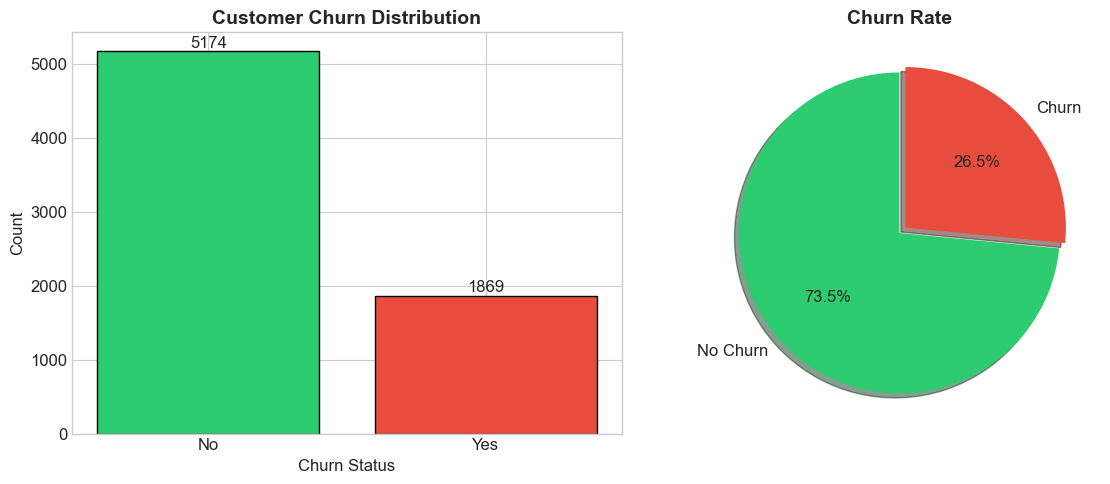

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
ax1 = axes[0]
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black')
ax1.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Count')
for bar, count in zip(bars, churn_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count}', ha='center', fontsize=12)

# Pie chart
ax2 = axes[1]
ax2.pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
        colors=colors, explode=[0, 0.05], shadow=True, startangle=90)
ax2.set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Numeric Variables Distribution

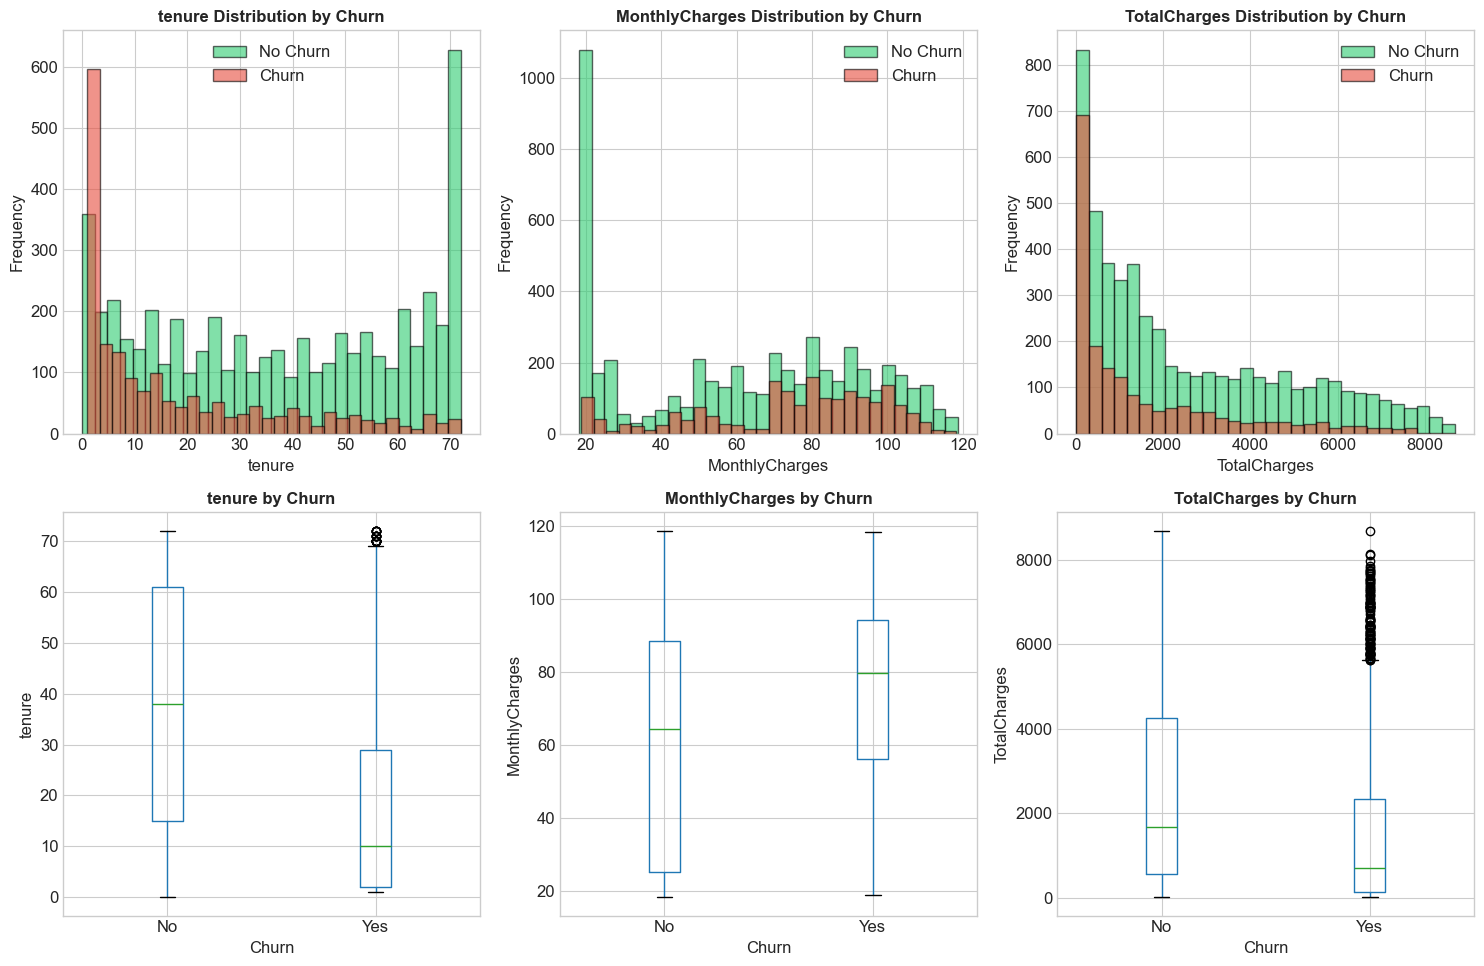

In [10]:
# Convert TotalCharges to numeric for analysis
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    # Histogram
    ax = axes[0, i]
    ax.hist(df_eda[df_eda['Churn'] == 'No'][col].dropna(), bins=30, alpha=0.6, 
            label='No Churn', color='#2ecc71', edgecolor='black')
    ax.hist(df_eda[df_eda['Churn'] == 'Yes'][col].dropna(), bins=30, alpha=0.6, 
            label='Churn', color='#e74c3c', edgecolor='black')
    ax.set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # Box plot
    ax = axes[1, i]
    df_eda.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)
    plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Churn Rate by Categorical Variables

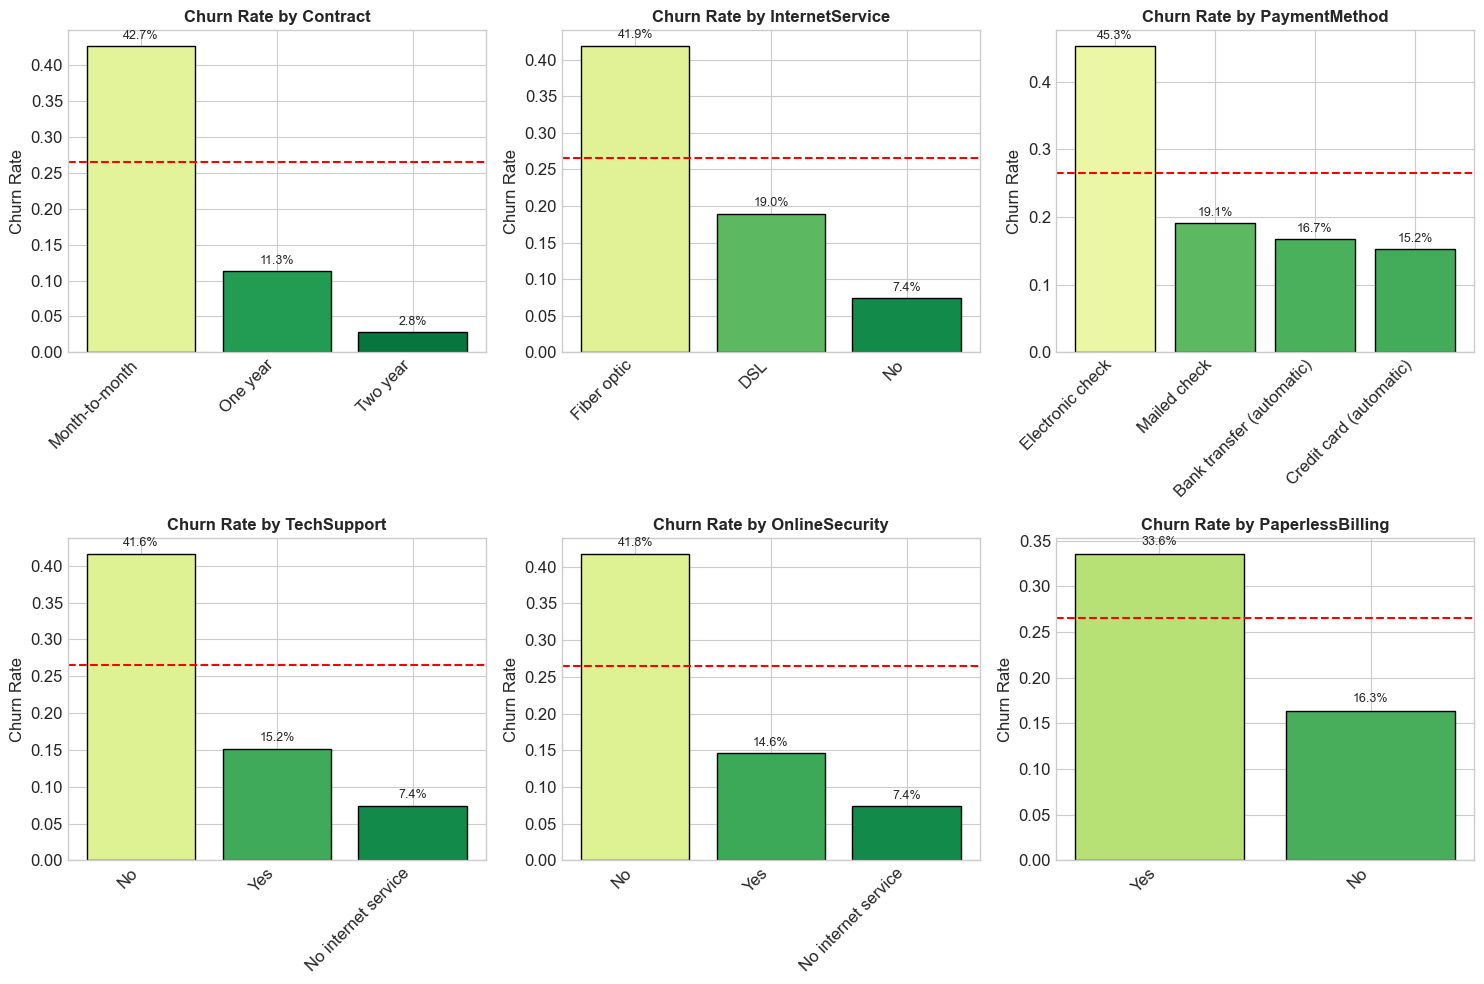

In [11]:
# Key categorical variables
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 
            'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Calculate churn rate by category
    churn_rate = df_eda.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    counts = df_eda[col].value_counts()
    
    # Sort by churn rate
    churn_rate = churn_rate.sort_values(ascending=False)
    
    bars = ax.bar(range(len(churn_rate)), churn_rate.values, 
                  color=plt.cm.RdYlGn_r(churn_rate.values), edgecolor='black')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=45, ha='right')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.axhline(y=df_eda['Churn'].apply(lambda x: x == 'Yes').mean(), 
               color='red', linestyle='--', label='Overall Churn Rate')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/churn_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Tenure Analysis

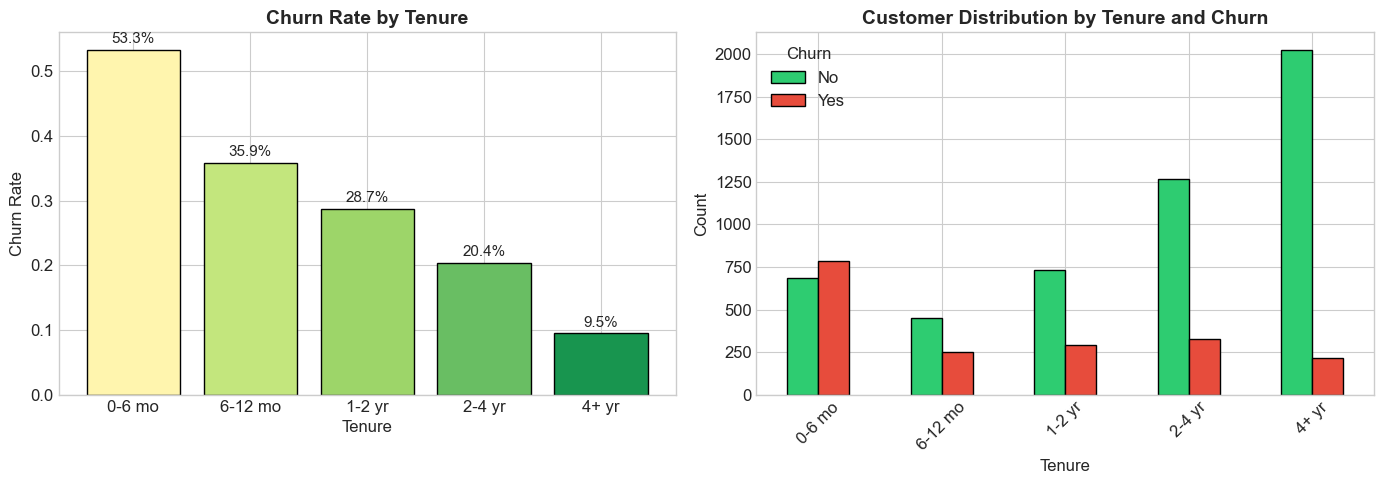

In [12]:
# Create tenure buckets
df_eda['tenure_bucket'] = pd.cut(df_eda['tenure'], 
                                  bins=[0, 6, 12, 24, 48, 72], 
                                  labels=['0-6 mo', '6-12 mo', '1-2 yr', '2-4 yr', '4+ yr'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by tenure bucket
ax1 = axes[0]
tenure_churn = df_eda.groupby('tenure_bucket')['Churn'].apply(lambda x: (x == 'Yes').mean())
tenure_churn = tenure_churn.reindex(['0-6 mo', '6-12 mo', '1-2 yr', '2-4 yr', '4+ yr'])

bars = ax1.bar(tenure_churn.index, tenure_churn.values, 
               color=plt.cm.RdYlGn_r(tenure_churn.values), edgecolor='black')
ax1.set_title('Churn Rate by Tenure', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tenure')
ax1.set_ylabel('Churn Rate')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{height:.1%}', ha='center', fontsize=11)

# Distribution of customers by tenure bucket and churn
ax2 = axes[1]
tenure_counts = df_eda.groupby(['tenure_bucket', 'Churn']).size().unstack()
tenure_counts = tenure_counts.reindex(['0-6 mo', '6-12 mo', '1-2 yr', '2-4 yr', '4+ yr'])
tenure_counts.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax2.set_title('Customer Distribution by Tenure and Churn', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tenure')
ax2.set_ylabel('Count')
ax2.legend(title='Churn')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/tenure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5 Correlation Analysis

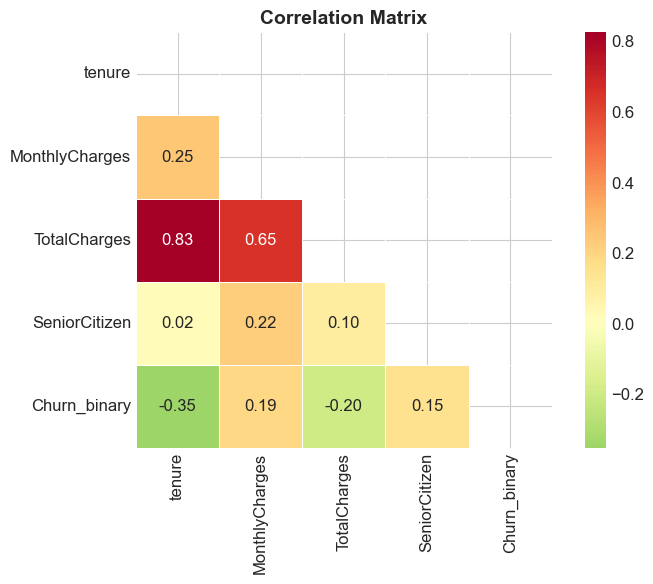

In [13]:
# Encode binary variables for correlation
df_corr = df_eda.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

# Numeric correlations with target
numeric_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = df_corr[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlGn_r', center=0,
            fmt='.2f', ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Data Cleaning and Preprocessing

In [14]:
# Create a clean copy
df_clean = df.copy()

# 1. Convert TotalCharges to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 2. Handle missing TotalCharges (these are new customers with tenure=0)
missing_mask = df_clean['TotalCharges'].isna()
print(f"Missing TotalCharges: {missing_mask.sum()}")
print(f"All missing are tenure=0: {(df_clean.loc[missing_mask, 'tenure'] == 0).all()}")

# Impute with 0 for new customers
df_clean.loc[missing_mask, 'TotalCharges'] = 0

# 3. Encode target variable
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nCleaned data shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Missing TotalCharges: 11
All missing are tenure=0: True

Cleaned data shape: (7043, 21)
Missing values: 0


In [15]:
# Prepare features and target
# Drop customerID (not a feature) and Churn (target)
feature_cols = [col for col in df_clean.columns if col not in ['customerID', 'Churn']]

X = df_clean[feature_cols]
y = df_clean['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [16]:
# Define feature types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cat_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                      'Contract', 'PaymentMethod']
passthrough_features = ['SeniorCitizen']  # Already 0/1

print(f"Numeric features: {len(numeric_features)}")
print(f"Binary features: {len(binary_features)}")
print(f"Multi-categorical features: {len(multi_cat_features)}")
print(f"Passthrough features: {len(passthrough_features)}")

Numeric features: 3
Binary features: 5
Multi-categorical features: 10
Passthrough features: 1


---
## 6. Train-Test Split

In [17]:
# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nChurn rate - Train: {y_train.mean():.2%}")
print(f"Churn rate - Test: {y_test.mean():.2%}")

Training set: 5634 samples
Test set: 1409 samples

Churn rate - Train: 26.54%
Churn rate - Test: 26.54%


---
## 7. Preprocessing Pipeline

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline (for all categorical variables)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all transformers
all_categorical = binary_features + multi_cat_features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, all_categorical),
        ('passthrough', 'passthrough', passthrough_features)
    ],
    remainder='drop'
)

# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training features shape: {X_train_processed.shape}")
print(f"Processed test features shape: {X_test_processed.shape}")

Processed training features shape: (5634, 45)
Processed test features shape: (1409, 45)


In [19]:
# Get feature names after preprocessing
def get_feature_names(preprocessor, numeric_features, all_categorical, passthrough_features):
    feature_names = []
    
    # Numeric features (keep original names)
    feature_names.extend(numeric_features)
    
    # One-hot encoded features
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
        ohe_features = ohe.get_feature_names_out(all_categorical).tolist()
        feature_names.extend(ohe_features)
    except:
        feature_names.extend(all_categorical)
    
    # Passthrough features
    feature_names.extend(passthrough_features)
    
    return feature_names

feature_names = get_feature_names(preprocessor, numeric_features, all_categorical, passthrough_features)
print(f"Total features after preprocessing: {len(feature_names)}")
print(f"\nFirst 10 features: {feature_names[:10]}")

Total features after preprocessing: 45

First 10 features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No']


---
## 8. Model Training and Comparison

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer

# Define models
class_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Majority Class Baseline': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', 
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                                     random_state=RANDOM_STATE)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        scale_pos_weight=class_weight_ratio,
        random_state=RANDOM_STATE, use_label_encoder=False, 
        eval_metric='logloss', verbosity=0
    )

print(f"Models to evaluate: {list(models.keys())}")

Models to evaluate: ['Majority Class Baseline', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [21]:
# Cross-validation with multiple metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # ROC-AUC
    roc_auc_scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc')
    
    # Recall
    recall_scores = cross_val_score(model, X_train_processed, y_train, cv=cv, 
                                    scoring=make_scorer(recall_score, pos_label=1))
    
    # Precision
    precision_scores = cross_val_score(model, X_train_processed, y_train, cv=cv,
                                       scoring=make_scorer(precision_score, pos_label=1, zero_division=0))
    
    # F1
    f1_scores = cross_val_score(model, X_train_processed, y_train, cv=cv,
                                scoring=make_scorer(f1_score, pos_label=1))
    
    results.append({
        'Model': name,
        'ROC-AUC': f"{roc_auc_scores.mean():.4f} ± {roc_auc_scores.std():.4f}",
        'ROC-AUC Mean': roc_auc_scores.mean(),
        'Recall': f"{recall_scores.mean():.4f} ± {recall_scores.std():.4f}",
        'Recall Mean': recall_scores.mean(),
        'Precision': f"{precision_scores.mean():.4f} ± {precision_scores.std():.4f}",
        'Precision Mean': precision_scores.mean(),
        'F1': f"{f1_scores.mean():.4f} ± {f1_scores.std():.4f}",
        'F1 Mean': f1_scores.mean()
    })
    
    print(f"  ROC-AUC: {roc_auc_scores.mean():.4f} ± {roc_auc_scores.std():.4f}")
    print(f"  Recall:  {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")


Evaluating Majority Class Baseline...


  ROC-AUC: 0.5000 ± 0.0000
  Recall:  0.0000 ± 0.0000

Evaluating Logistic Regression...
  ROC-AUC: 0.8460 ± 0.0124
  Recall:  0.8007 ± 0.0370

Evaluating Decision Tree...
  ROC-AUC: 0.7488 ± 0.0083
  Recall:  0.6816 ± 0.0201

Evaluating Random Forest...
  ROC-AUC: 0.8292 ± 0.0097
  Recall:  0.5525 ± 0.0153

Evaluating Gradient Boosting...
  ROC-AUC: 0.8387 ± 0.0083
  Recall:  0.5124 ± 0.0308

Evaluating XGBoost...
  ROC-AUC: 0.8447 ± 0.0101
  Recall:  0.7672 ± 0.0296


In [22]:
# Display results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC Mean', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS (Cross-Validation)")
print("="*80)
print(results_df[['Model', 'ROC-AUC', 'Recall', 'Precision', 'F1']].to_string(index=False))


MODEL COMPARISON RESULTS (Cross-Validation)
                  Model         ROC-AUC          Recall       Precision              F1
    Logistic Regression 0.8460 ± 0.0124 0.8007 ± 0.0370 0.5168 ± 0.0195 0.6279 ± 0.0233
                XGBoost 0.8447 ± 0.0101 0.7672 ± 0.0296 0.5404 ± 0.0132 0.6341 ± 0.0188
      Gradient Boosting 0.8387 ± 0.0083 0.5124 ± 0.0308 0.6401 ± 0.0288 0.5686 ± 0.0251
          Random Forest 0.8292 ± 0.0097 0.5525 ± 0.0153 0.6237 ± 0.0206 0.5856 ± 0.0115
          Decision Tree 0.7488 ± 0.0083 0.6816 ± 0.0201 0.4941 ± 0.0149 0.5728 ± 0.0160
Majority Class Baseline 0.5000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000


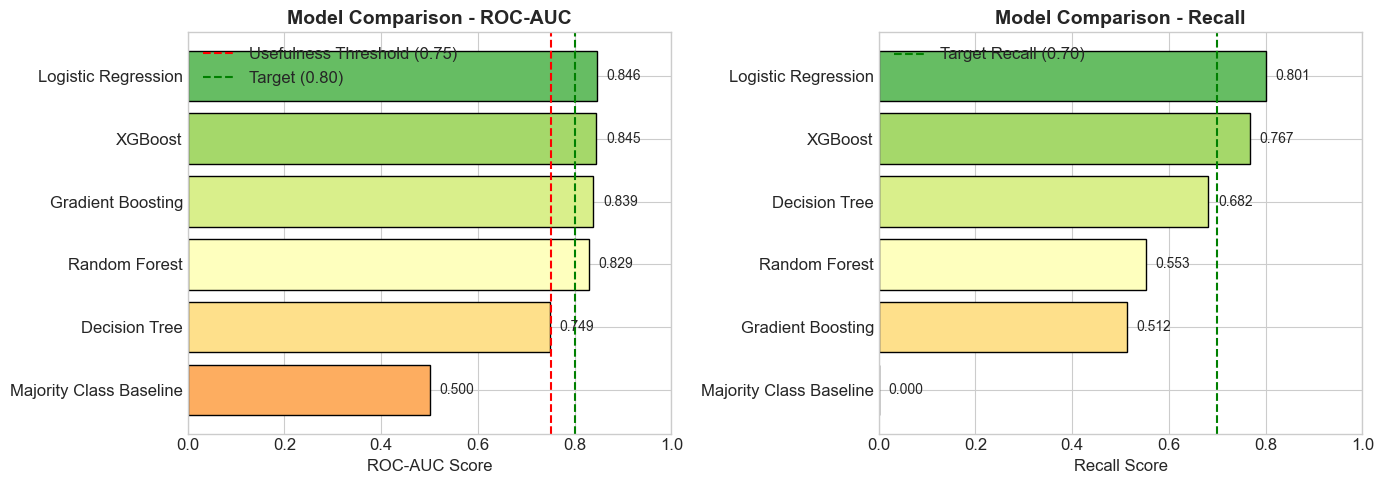

In [23]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC comparison
ax1 = axes[0]
models_sorted = results_df.sort_values('ROC-AUC Mean')['Model'].tolist()
roc_means = results_df.sort_values('ROC-AUC Mean')['ROC-AUC Mean'].tolist()

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(models_sorted)))
bars = ax1.barh(models_sorted, roc_means, color=colors, edgecolor='black')
ax1.axvline(x=0.75, color='red', linestyle='--', label='Usefulness Threshold (0.75)')
ax1.axvline(x=0.80, color='green', linestyle='--', label='Target (0.80)')
ax1.set_xlabel('ROC-AUC Score')
ax1.set_title('Model Comparison - ROC-AUC', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_xlim(0, 1)

for bar, score in zip(bars, roc_means):
    ax1.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', va='center', fontsize=10)

# Recall comparison
ax2 = axes[1]
models_sorted_recall = results_df.sort_values('Recall Mean')['Model'].tolist()
recall_means = results_df.sort_values('Recall Mean')['Recall Mean'].tolist()

bars = ax2.barh(models_sorted_recall, recall_means, color=colors, edgecolor='black')
ax2.axvline(x=0.70, color='green', linestyle='--', label='Target Recall (0.70)')
ax2.set_xlabel('Recall Score')
ax2.set_title('Model Comparison - Recall', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_xlim(0, 1)

for bar, score in zip(bars, recall_means):
    ax2.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 9. Train Final Model and Evaluate on Test Set

In [24]:
# Select the best model (excluding baseline)
best_model_name = results_df[results_df['Model'] != 'Majority Class Baseline'].iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Train final model on full training set
final_model = models[best_model_name]
final_model.fit(X_train_processed, y_train)

print(f"\nModel trained on {len(X_train)} samples")

Best model: Logistic Regression

Model trained on 5634 samples


In [25]:
# Make predictions on test set
y_pred_proba = final_model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_pr_auc = average_precision_score(y_test, y_pred_proba)

print("\n" + "="*60)
print(f"FINAL MODEL EVALUATION: {best_model_name}")
print("="*60)
print(f"\nTest Set Metrics (Threshold = 0.5):")
print(f"  ROC-AUC:     {test_roc_auc:.4f}")
print(f"  PR-AUC:      {test_pr_auc:.4f}")
print(f"  Recall:      {test_recall:.4f}")
print(f"  Precision:   {test_precision:.4f}")
print(f"  F1 Score:    {test_f1:.4f}")

# Check success criteria
print(f"\nSuccess Criteria Check:")
print(f"  ROC-AUC >= 0.80: {test_roc_auc:.4f} {'✓' if test_roc_auc >= 0.80 else '✗'}")
print(f"  Recall >= 0.70:  {test_recall:.4f} {'✓' if test_recall >= 0.70 else '✗'}")


FINAL MODEL EVALUATION: Logistic Regression

Test Set Metrics (Threshold = 0.5):
  ROC-AUC:     0.8416
  PR-AUC:      0.6326
  Recall:      0.7834
  Precision:   0.5043
  F1 Score:    0.6136

Success Criteria Check:
  ROC-AUC >= 0.80: 0.8416 ✓
  Recall >= 0.70:  0.7834 ✓


In [26]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



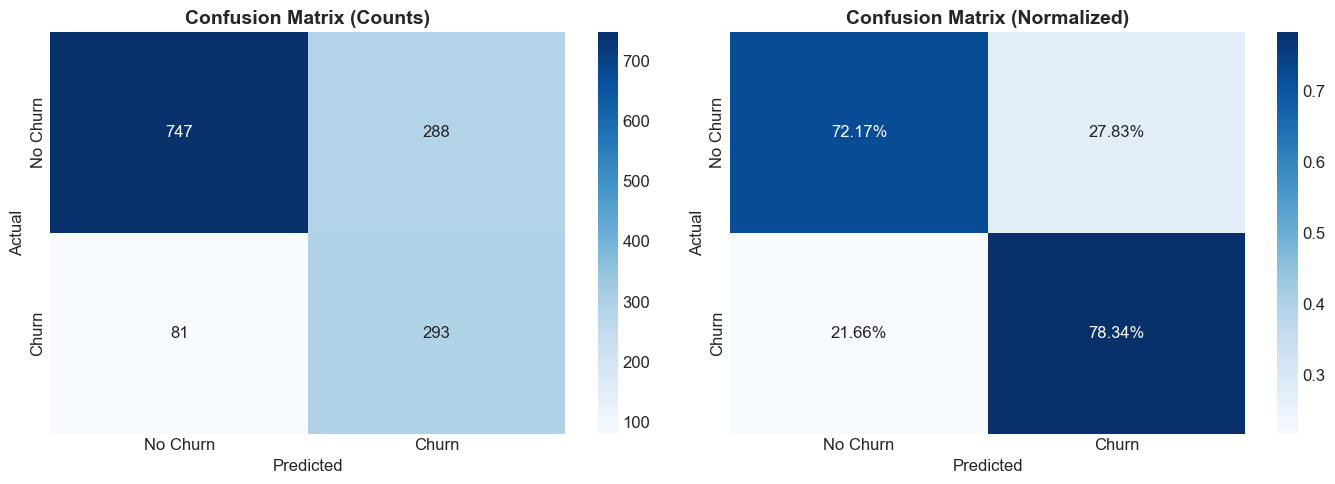

In [27]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ax2 = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 10. Threshold Optimization

In [28]:
# Find optimal threshold for different objectives
thresholds = np.arange(0.1, 0.9, 0.01)

threshold_results = []
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    threshold_results.append({
        'threshold': thresh,
        'recall': recall_score(y_test, y_pred_thresh),
        'precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'f1': f1_score(y_test, y_pred_thresh),
        'specificity': recall_score(y_test, y_pred_thresh, pos_label=0)
    })

threshold_df = pd.DataFrame(threshold_results)

# Find optimal thresholds
optimal_f1_thresh = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
optimal_f1_metrics = threshold_df.loc[threshold_df['f1'].idxmax()]

# Find threshold for minimum 70% recall
valid_recall = threshold_df[threshold_df['recall'] >= 0.70]
if len(valid_recall) > 0:
    optimal_recall_thresh = valid_recall.loc[valid_recall['f1'].idxmax(), 'threshold']
    optimal_recall_metrics = valid_recall.loc[valid_recall['f1'].idxmax()]
else:
    optimal_recall_thresh = threshold_df.loc[threshold_df['recall'].idxmax(), 'threshold']
    optimal_recall_metrics = threshold_df.loc[threshold_df['recall'].idxmax()]

print(f"Optimal F1 Threshold: {optimal_f1_thresh:.2f}")
print(f"  Recall: {optimal_f1_metrics['recall']:.4f}")
print(f"  Precision: {optimal_f1_metrics['precision']:.4f}")
print(f"  F1: {optimal_f1_metrics['f1']:.4f}")

print(f"\nOptimal Threshold for 70% Recall: {optimal_recall_thresh:.2f}")
print(f"  Recall: {optimal_recall_metrics['recall']:.4f}")
print(f"  Precision: {optimal_recall_metrics['precision']:.4f}")
print(f"  F1: {optimal_recall_metrics['f1']:.4f}")

Optimal F1 Threshold: 0.54
  Recall: 0.7647
  Precision: 0.5238
  F1: 0.6217

Optimal Threshold for 70% Recall: 0.54
  Recall: 0.7647
  Precision: 0.5238
  F1: 0.6217


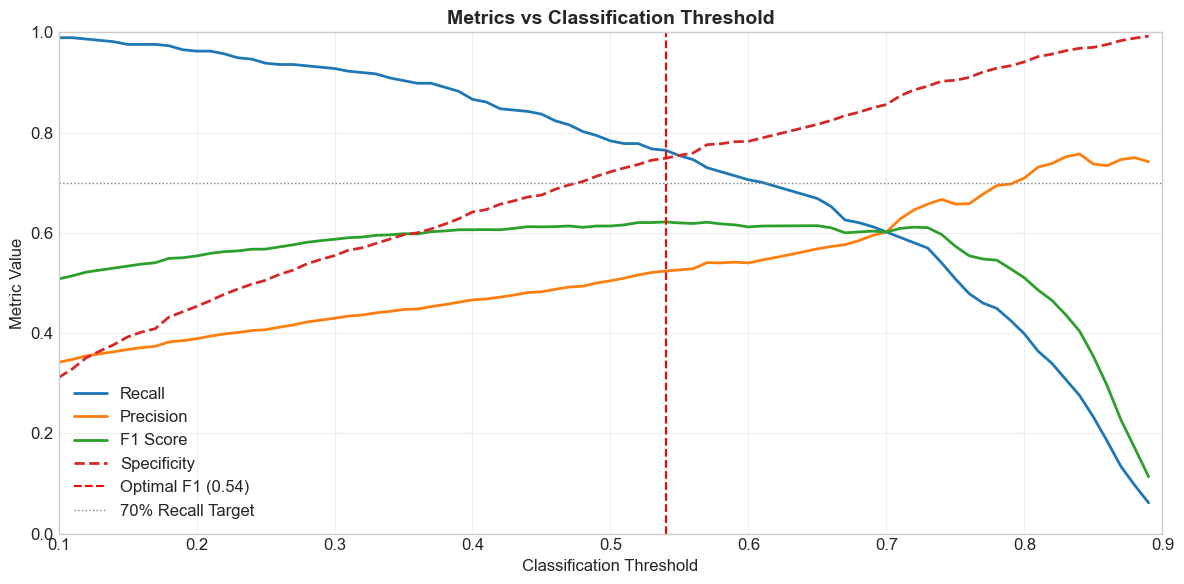

In [29]:
# Plot threshold analysis
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['f1'], label='F1 Score', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['specificity'], label='Specificity', linewidth=2, linestyle='--')

ax.axvline(x=optimal_f1_thresh, color='red', linestyle='--', 
           label=f'Optimal F1 ({optimal_f1_thresh:.2f})', linewidth=1.5)
ax.axhline(y=0.70, color='gray', linestyle=':', label='70% Recall Target', linewidth=1)

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 11. ROC and Precision-Recall Curves

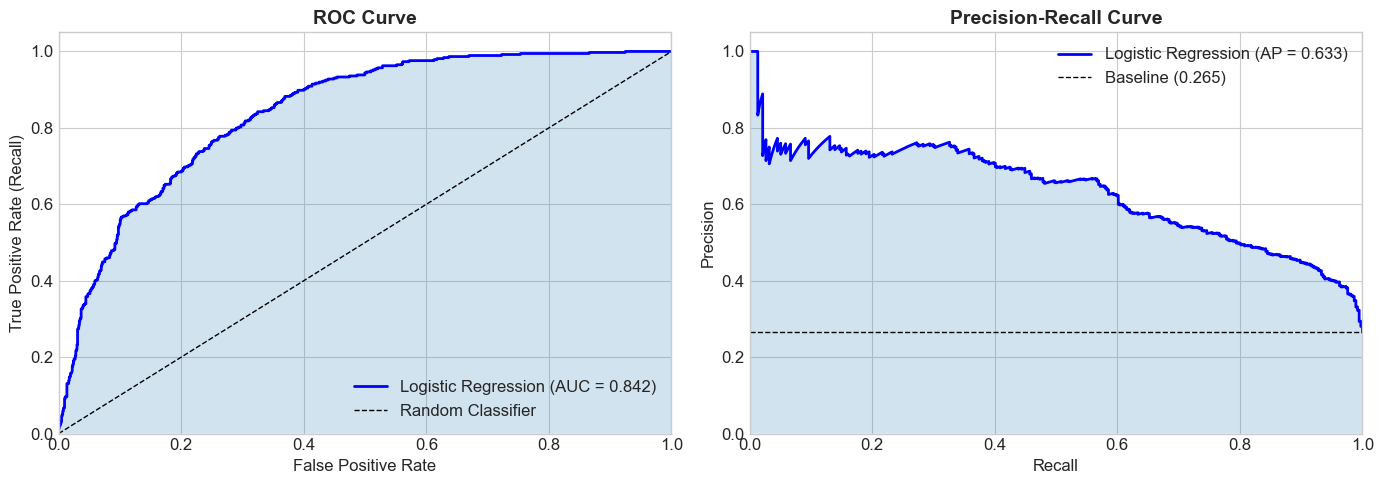

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax1.plot(fpr, tpr, label=f'{best_model_name} (AUC = {test_roc_auc:.3f})', linewidth=2, color='blue')
ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax1.fill_between(fpr, tpr, alpha=0.2)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# PR Curve
ax2 = axes[1]
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax2.plot(recall_curve, precision_curve, label=f'{best_model_name} (AP = {test_pr_auc:.3f})', 
         linewidth=2, color='blue')
baseline = y_test.mean()
ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})', linewidth=1)
ax2.fill_between(recall_curve, precision_curve, alpha=0.2)
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 12. Feature Importance Analysis

In [31]:
# Extract feature importance (depends on model type)
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    importance_type = 'Built-in'
elif hasattr(final_model, 'coef_'):
    importances = np.abs(final_model.coef_[0])
    importance_type = 'Coefficient Magnitude'
else:
    print("Cannot extract feature importance from this model type")
    importances = None

if importances is not None:
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 15 Features ({importance_type} Importance):")
    print(importance_df.head(15).to_string(index=False))


Top 15 Features (Coefficient Magnitude Importance):
                             feature  importance
                              tenure    1.152603
                   Contract_Two year    0.775929
         InternetService_Fiber optic    0.712397
                      MonthlyCharges    0.687704
             Contract_Month-to-month    0.655964
                 InternetService_DSL    0.627775
                        TotalCharges    0.487295
    OnlineBackup_No internet service    0.279201
DeviceProtection_No internet service    0.279201
  OnlineSecurity_No internet service    0.279201
                  InternetService_No    0.279201
     TechSupport_No internet service    0.279201
     StreamingTV_No internet service    0.279201
 StreamingMovies_No internet service    0.279201
                 StreamingMovies_Yes    0.276794


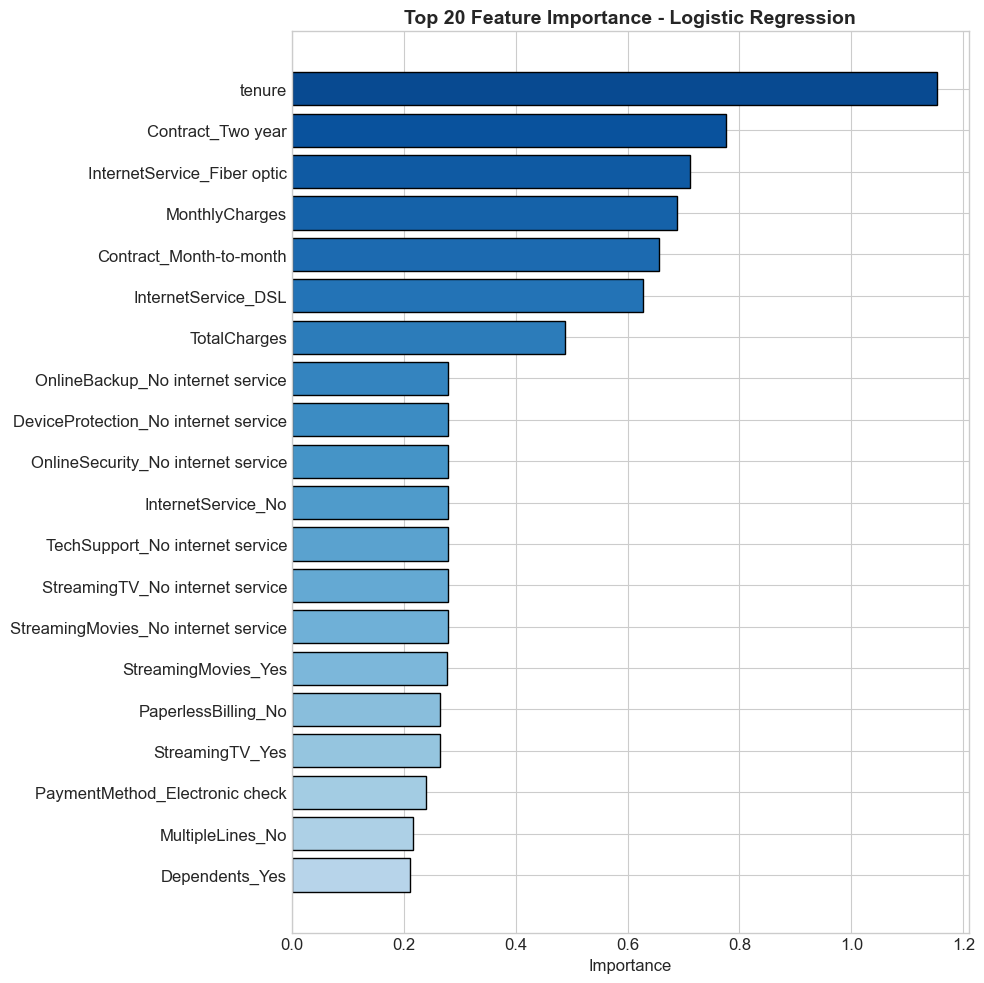

In [32]:
# Plot feature importance
if importances is not None:
    fig, ax = plt.subplots(figsize=(10, 10))
    
    top_n = 20
    top_features = importance_df.head(top_n)
    
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, top_n))[::-1]
    ax.barh(range(top_n), top_features['importance'].values, color=colors, edgecolor='black')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features['feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

---
## 13. SHAP Analysis (if available)

In [33]:
if SHAP_AVAILABLE:
    print("Computing SHAP values...")
    
    # Use a sample for faster computation
    n_samples = min(500, len(X_test_processed))
    sample_indices = np.random.choice(len(X_test_processed), n_samples, replace=False)
    X_sample = X_test_processed[sample_indices]
    
    # Create explainer based on model type
    if hasattr(final_model, 'feature_importances_'):
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # For binary classification, take positive class
    else:
        # For other models, use KernelExplainer (slower)
        background = shap.sample(X_train_processed, 100)
        explainer = shap.KernelExplainer(final_model.predict_proba, background)
        shap_values = explainer.shap_values(X_sample[:100])  # Smaller sample
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    
    print(f"SHAP values computed for {len(shap_values)} samples")
else:
    print("SHAP not available. Install with: pip install shap")

Computing SHAP values...


100%|██████████| 100/100 [00:25<00:00,  3.88it/s]

SHAP values computed for 100 samples


AssertionError: Feature and SHAP matrices must have the same number of rows!

<Figure size 1200x800 with 0 Axes>

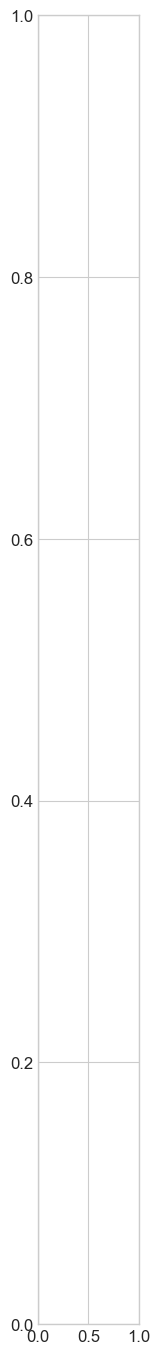

In [34]:
if SHAP_AVAILABLE and 'shap_values' in dir():
    # Summary plot (bar)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                      plot_type='bar', show=False, max_display=20)
    plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_importance_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
if SHAP_AVAILABLE and 'shap_values' in dir():
    # Summary plot (dot)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                      show=False, max_display=20)
    plt.title('SHAP Summary Plot', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_summary_dot.png', dpi=300, bbox_inches='tight')
    plt.show()

---
## 14. Save Model Artifacts

In [ ]:
# Timestamp erstellen
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create folder
os.makedirs('../models', exist_ok=True)

# Save model
model_path = f'../models/churn_model_{best_model_name.lower().replace(" ", "_")}_{timestamp}.joblib'
joblib.dump(final_model, model_path)
print(f"Model saved to: {model_path}")

# Save preprocessor
preprocessor_path = f'../models/preprocessor_{timestamp}.joblib'
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to: {preprocessor_path}")

# Save metadata
metadata = {
    'timestamp': timestamp,
    'model_name': best_model_name,
    'optimal_threshold': float(optimal_recall_thresh),
    'feature_names': feature_names,
    'metrics': {
        'roc_auc': float(test_roc_auc),
        'pr_auc': float(test_pr_auc),
        'recall': float(test_recall),
        'precision': float(test_precision),
        'f1': float(test_f1)
    },
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'random_state': RANDOM_STATE
}

metadata_path = f'../models/metadata_{timestamp}.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {metadata_path}")

# Also save as 'latest' for easy access
joblib.dump(final_model, '../models/churn_model_latest.joblib')
joblib.dump(preprocessor, '../models/preprocessor_latest.joblib')
with open('../models/metadata_latest.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("\nLatest model artifacts saved")

---
## 15. Summary and Conclusions

In [ ]:
print("="*80)
print("\033[1mPROJECT SUMMARY\033[0m")
print("="*80)

print(f"\n\033[1mDataset Overview:\033[0m")
print(f"   - Total samples: {len(df)}")
print(f"   - Features: {len(feature_cols)}")
print(f"   - Churn rate: {(df['Churn'] == 'Yes').mean():.2%}")

print(f"\n\033[1mBest Model:\033[0m {best_model_name}")

print(f"\n\033[1mTest Set Performance:\033[0m")
print(f"   - ROC-AUC:   {test_roc_auc:.4f}")
print(f"   - PR-AUC:    {test_pr_auc:.4f}")
print(f"   - Recall:    {test_recall:.4f}")
print(f"   - Precision: {test_precision:.4f}")
print(f"   - F1 Score:  {test_f1:.4f}")

print(f"\n\033[1mOptimal Threshold:\033[0m {optimal_recall_thresh:.2f}")
print(f"   (Achieves {optimal_recall_metrics['recall']:.1%} recall with {optimal_recall_metrics['precision']:.1%} precision)")

print(f"\n\033[1mSuccess Criteria:\033[0m")
print(f"   - ROC-AUC >= 0.80: {' PASSED' if test_roc_auc >= 0.80 else ' NOT MET'}")
print(f"   - Recall >= 0.70:  {' PASSED' if optimal_recall_metrics['recall'] >= 0.70 else ' NOT MET'}")

print(f"\n\033[1mTop 5 Churn Drivers:\033[0m")
if importances is not None:
    for i, (feat, imp) in enumerate(importance_df.head(5).values, 1):
        print(f"   {i}. {feat}: {imp:.4f}")

print(f"\n\033[1mModel artifacts saved to:\033[0m ../models/")
print(f"\033[1mVisualizations saved to:\033[0m ../reports/figures/")

---
## End of Notebook